# 📝 언어학적 피처 분석 (Linguistic Feature Analysis)
구두점(Punctuation), 문장 구조(Sentence Structure), 형태소(POS) 기반의 Human vs AI 텍스트 분석

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from konlpy.tag import Okt, Mecab
from collections import Counter
from tqdm import tqdm
import platform
import re

# 한글 폰트 설정
def set_korean_font():
    candidates = []
    system = platform.system()
    if system == 'Darwin':
        candidates = ['AppleGothic', 'NanumGothic', 'NanumBarunGothic']
    elif system == 'Windows':
        candidates = ['Malgun Gothic', 'Dotum', 'Gulim']
    else:
        candidates = ['NanumGothic', 'NanumBarunGothic', 'NanumMyeongjo']
    available_fonts = set([f.name for f in fm.fontManager.ttflist])
    for font in candidates:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            print(f'✅ 한글 폰트 설정: {font}')
            return
    print('⚠️ 한글 폰트를 찾지 못했습니다.')

set_korean_font()

In [30]:
# 데이터 로드 및 샘플링
data_path = '/Users/youngjinson/Downloads/open/train.csv'
df = pd.read_csv(data_path)

# 균형 샘플링 (분석 속도를 위해 각 200개)
n_sample = 1000
df_human = df[df['generated'] == 0].sample(n=n_sample, random_state=42)
df_ai = df[df['generated'] == 1].sample(n=min(n_sample, len(df[df['generated']==1])), random_state=42)
sample_df = pd.concat([df_human, df_ai]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"📊 분석 데이터: {len(sample_df)}개 (Human {len(df_human)}, AI {len(df_ai)})")

📊 분석 데이터: 2000개 (Human 1000, AI 1000)


In [ ]:
# 형태소 분석기 초기화 (Mecab > Okt 우선)
try:
    tagger = Mecab()
    print("✅ Mecab 사용")
except:
    print("⚠️ Mecab 미설치/오류 -> Okt 사용")
    tagger = Okt()

In [ ]:
# 언어학적 피처 추출 함수
def extract_linguistic_features(text):
    text_len = len(text)
    if text_len == 0:
        return {}

    # A. 구두점 분석 (Punctuation Density)
    comma_count = text.count(',')
    period_count = text.count('.')
    q_mark_count = text.count('?')
    e_mark_count = text.count('!')

    # B. 형태소(POS) 기반 분석
    try:
        pos = tagger.pos(text)
        if isinstance(tagger, Mecab):
            connective_endings = sum(1 for w, t in pos if t.startswith('EC'))
            adverbs = sum(1 for w, t in pos if t.startswith('MAG'))
            foreign = sum(1 for w, t in pos if t.startswith('SL'))
            nouns = sum(1 for w, t in pos if t.startswith('NN'))
        else:
            pos = tagger.pos(text)
            connective_endings = sum(1 for w, t in pos if t == 'Josa')
            adverbs = sum(1 for w, t in pos if t == 'Adverb')
            foreign = sum(1 for w, t in pos if t == 'Alpha')
            nouns = sum(1 for w, t in pos if t == 'Noun')
    except Exception:
        pos = []
        connective_endings, adverbs, foreign, nouns = 0, 0, 0, 0

    # C. 문장 구조 분석
    sentences = re.split(r'[.?!]\s+', text)
    sentences = [s for s in sentences if len(s.strip()) > 0]
    avg_sent_len = np.mean([len(s) for s in sentences]) if sentences else 0
    sent_len_std = np.std([len(s) for s in sentences]) if sentences else 0

    total_pos = len(pos) if len(pos) > 0 else 1

    return {
        'comma_density': (comma_count / text_len) * 1000,
        'period_density': (period_count / text_len) * 1000,
        'q_mark_density': (q_mark_count / text_len) * 1000,
        'connective_ratio': connective_endings / total_pos,
        'adverb_ratio': adverbs / total_pos,
        'foreign_ratio': foreign / total_pos,
        'avg_sentence_len': avg_sent_len,
        'sent_len_std': sent_len_std
    }

In [ ]:
# 피처 추출 실행
print("🚀 언어학적 피처 추출 시작...")
features_list = []
for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    feats = extract_linguistic_features(row['full_text'])
    feats['generated'] = row['generated']
    features_list.append(feats)

ling_df = pd.DataFrame(features_list)
ling_df['label'] = ling_df['generated'].map({0: 'Human', 1: 'AI'})
ling_df.head()

In [ ]:
# 시각화 (KDE Plot)
features_to_plot = [
    'comma_density', 'period_density', 'sent_len_std',
    'connective_ratio', 'adverb_ratio', 'foreign_ratio'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(data=ling_df, x=col, hue='label', fill=True, common_norm=False, palette='coolwarm')
    plt.title(f'{col} Distribution')

plt.tight_layout()
plt.show()

In [ ]:
# 통계 요약
print("\n📊 Feature Summary (Mean by Label):")
display(ling_df.groupby('label')[features_to_plot].mean())

---
## 📈 시퀀스 분석 (Sequence / Positional Analysis)
문장의 **순서(Position)**와 **길이 변화 패턴(Transition)**을 분석하여 글 구조의 차이를 탐색

In [ ]:
def get_sentence_sequence_features(text):
    """문장 단위로 분리 후, 위치별 길이 시퀀스 추출"""
    sentences = re.split(r'[.?!]\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]
    
    if len(sentences) < 3:
        return None  # 문장이 너무 적으면 분석 불가
    
    lengths = [len(s) for s in sentences]
    n = len(lengths)
    
    # 위치별 평균 (앞 1/3, 중간 1/3, 끝 1/3)
    third = n // 3
    if third == 0:
        third = 1
    opening_avg = np.mean(lengths[:third])
    middle_avg = np.mean(lengths[third:2*third])
    closing_avg = np.mean(lengths[2*third:])
    
    # Transition (문장 간 길이 변화량)
    transitions = np.diff(lengths)  # [len2-len1, len3-len2, ...]
    transition_mean = np.mean(np.abs(transitions))  # 평균 변화 폭
    transition_std = np.std(transitions)  # 변화 패턴의 일관성
    
    # 문장 길이 변화 방향 (증가 vs 감소 비율)
    increase_ratio = np.sum(transitions > 0) / len(transitions) if len(transitions) > 0 else 0.5
    
    return {
        'opening_len': opening_avg,
        'middle_len': middle_avg,
        'closing_len': closing_avg,
        'len_change_mean': transition_mean,  # 높으면 문장 길이가 급격히 변함
        'len_change_std': transition_std,    # 높으면 변화 패턴이 불규칙
        'increase_ratio': increase_ratio     # 0.5에 가까우면 균등, 1에 가까우면 계속 증가
    }

In [ ]:
# 시퀀스 피처 추출
print("🚀 시퀀스 피처 추출 시작...")
seq_features_list = []
for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    feats = get_sentence_sequence_features(row['full_text'])
    if feats is not None:
        feats['generated'] = row['generated']
        seq_features_list.append(feats)

seq_df = pd.DataFrame(seq_features_list)
seq_df['label'] = seq_df['generated'].map({0: 'Human', 1: 'AI'})
print(f"✅ 유효 샘플 수: {len(seq_df)}")
seq_df.head()

In [ ]:
# 위치별 문장 길이 시각화 (Opening vs Middle vs Closing)
pos_cols = ['opening_len', 'middle_len', 'closing_len']
pos_means = seq_df.groupby('label')[pos_cols].mean()

pos_means.T.plot(kind='bar', figsize=(10, 5), colormap='coolwarm')
plt.title('Sentence Length by Position (Opening / Middle / Closing)')
plt.ylabel('Mean Sentence Length (chars)')
plt.xlabel('Position in Document')
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.tight_layout()
plt.show()

In [ ]:
# Transition 피처 시각화 (문장 간 변화 패턴)
transition_cols = ['len_change_mean', 'len_change_std', 'increase_ratio']

plt.figure(figsize=(15, 4))
for i, col in enumerate(transition_cols):
    plt.subplot(1, 3, i+1)
    sns.kdeplot(data=seq_df, x=col, hue='label', fill=True, common_norm=False, palette='coolwarm')
    plt.title(f'{col} Distribution')

plt.tight_layout()
plt.show()

In [ ]:
# 시퀀스 피처 통계 요약
print("\n📊 Sequence Feature Summary (Mean by Label):")
display(seq_df.groupby('label')[pos_cols + transition_cols].mean())

---
## 🧬 고급 분석: 품사(POS) 시퀀스 패턴
문장 내 품사 태그 순서를 분석하여 Human과 AI의 **문장 구조 차이**를 탐색

In [31]:
def get_pos_sequence_features(text):
    """문장별 POS 시퀀스 분석: 시작/끝 패턴, N-gram 다양성"""
    sentences = re.split(r'[.?!]\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    
    if len(sentences) < 2:
        return None
    
    opening_tags = []  # 각 문장의 첫 2개 품사
    closing_tags = []  # 각 문장의 마지막 2개 품사
    all_bigrams = []   # 전체 POS Bigram
    
    for sent in sentences:
        try:
            pos = tagger.pos(sent)
            tags = [t for w, t in pos]
            
            if len(tags) >= 2:
                opening_tags.append(tuple(tags[:2]))
                closing_tags.append(tuple(tags[-2:]))
            
            # POS Bigrams
            for i in range(len(tags) - 1):
                all_bigrams.append((tags[i], tags[i+1]))
        except:
            continue
    
    if len(opening_tags) == 0 or len(all_bigrams) == 0:
        return None
    
    # Opening/Closing 패턴 다양성 (Unique / Total)
    opening_diversity = len(set(opening_tags)) / len(opening_tags)
    closing_diversity = len(set(closing_tags)) / len(closing_tags)
    
    # Bigram 다양성
    bigram_diversity = len(set(all_bigrams)) / len(all_bigrams)
    
    # 가장 흔한 Opening 패턴 빈도 (Top-1 비율)
    opening_counter = Counter(opening_tags)
    top_opening_ratio = opening_counter.most_common(1)[0][1] / len(opening_tags)
    
    # 가장 흔한 Closing 패턴 빈도
    closing_counter = Counter(closing_tags)
    top_closing_ratio = closing_counter.most_common(1)[0][1] / len(closing_tags)
    
    return {
        'opening_diversity': opening_diversity,   # 높으면 문장 시작이 다양함
        'closing_diversity': closing_diversity,   # 높으면 문장 끝이 다양함
        'bigram_diversity': bigram_diversity,     # 높으면 전체 품사 패턴이 다양함
        'top_opening_ratio': top_opening_ratio,   # 높으면 같은 패턴으로 시작하는 문장 많음 (AI 의심)
        'top_closing_ratio': top_closing_ratio    # 높으면 같은 패턴으로 끝나는 문장 많음
    }

In [32]:
# POS 시퀀스 피처 추출
print("🚀 POS 시퀀스 피처 추출 시작...")
pos_seq_list = []
for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    feats = get_pos_sequence_features(row['full_text'])
    if feats is not None:
        feats['generated'] = row['generated']
        pos_seq_list.append(feats)

pos_seq_df = pd.DataFrame(pos_seq_list)
pos_seq_df['label'] = pos_seq_df['generated'].map({0: 'Human', 1: 'AI'})
print(f"✅ 유효 샘플 수: {len(pos_seq_df)}")
pos_seq_df.head()

🚀 POS 시퀀스 피처 추출 시작...


100%|██████████| 2000/2000 [00:02<00:00, 816.18it/s]

✅ 유효 샘플 수: 2000


,opening_diversity,closing_diversity,bigram_diversity,top_opening_ratio,top_closing_ratio,generated,label
0,0.397260,0.383562,0.168385,0.178082,0.123288,1,AI
1,0.571429,0.785714,0.279693,0.285714,0.285714,0,Human
2,0.642857,0.714286,0.414493,0.285714,0.142857,1,AI
3,0.515152,0.424242,0.182944,0.272727,0.242424,0,Human
4,0.666667,0.533333,0.350975,0.200000,0.200000,1,AI


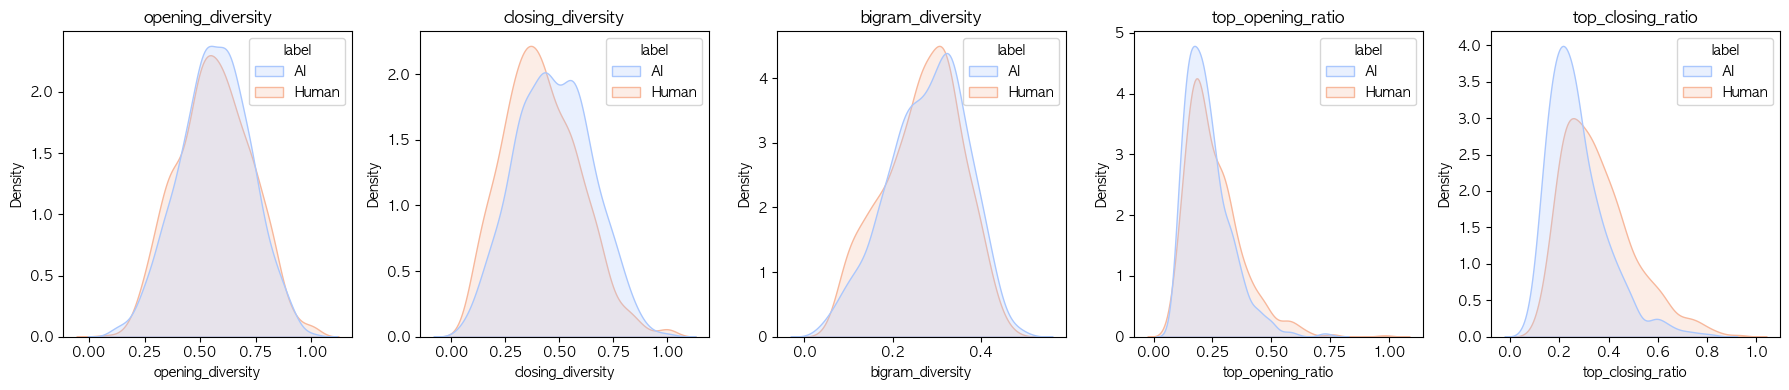

In [33]:
# POS 시퀀스 피처 시각화
pos_seq_cols = ['opening_diversity', 'closing_diversity', 'bigram_diversity', 'top_opening_ratio', 'top_closing_ratio']

plt.figure(figsize=(18, 4))
for i, col in enumerate(pos_seq_cols):
    plt.subplot(1, 5, i+1)
    sns.kdeplot(data=pos_seq_df, x=col, hue='label', fill=True, common_norm=False, palette='coolwarm')
    plt.title(f'{col}')

plt.tight_layout()
plt.show()

In [34]:
# POS 시퀀스 피처 통계 요약
print("\n📊 POS Sequence Feature Summary (Mean by Label):")
display(pos_seq_df.groupby('label')[pos_seq_cols].mean())


📊 POS Sequence Feature Summary (Mean by Label):


,opening_diversity,closing_diversity,bigram_diversity,top_opening_ratio,top_closing_ratio
label,,,,,
AI,0.564548,0.472779,0.278081,0.229012,0.273215
Human,0.562638,0.417213,0.266591,0.255870,0.356194


In [35]:
# 최빈 Opening/Closing 패턴 비교
def get_top_patterns(text_series, pattern_type='opening'):
    all_patterns = []
    for text in text_series:
        sentences = re.split(r'[.?!]\s+', text)
        for sent in sentences:
            sent = sent.strip()
            if len(sent) < 10:
                continue
            try:
                pos = tagger.pos(sent)
                tags = [t for w, t in pos]
                if len(tags) >= 2:
                    if pattern_type == 'opening':
                        all_patterns.append(tuple(tags[:2]))
                    else:
                        all_patterns.append(tuple(tags[-2:]))
            except:
                continue
    return Counter(all_patterns).most_common(5)

print("\n📌 Top 5 Opening Patterns (문장 시작 품사 패턴):")
print(f"  Human: {get_top_patterns(sample_df[sample_df['generated']==0]['full_text'], 'opening')}")
print(f"  AI:    {get_top_patterns(sample_df[sample_df['generated']==1]['full_text'], 'opening')}")

print("\n📌 Top 5 Closing Patterns (문장 끝 품사 패턴):")
print(f"  Human: {get_top_patterns(sample_df[sample_df['generated']==0]['full_text'], 'closing')}")
print(f"  AI:    {get_top_patterns(sample_df[sample_df['generated']==1]['full_text'], 'closing')}")


📌 Top 5 Opening Patterns (문장 시작 품사 패턴):
  Human: [(('NNG', 'NNG'), 4057), (('SN', 'NNBC'), 4029), (('MM', 'NNG'), 1947), (('NNP', 'NNG'), 1778), (('NNG', 'JX'), 1426)]
  AI:    [(('SN', 'NNBC'), 4659), (('NNG', 'NNG'), 4603), (('MM', 'NNG'), 2580), (('NNP', 'NNG'), 2097), (('NNG', 'JX'), 1625)]

📌 Top 5 Closing Patterns (문장 끝 품사 패턴):
  Human: [(('EP', 'EC'), 9291), (('XSV+EP', 'EC'), 3519), (('VCP', 'EC'), 3390), (('VV+EP', 'EC'), 2951), (('NNG', 'XSV+EC'), 2403)]
  AI:    [(('EP', 'EC'), 7077), (('XSV+EP', 'EC'), 3247), (('EP', 'EF'), 2694), (('VV+EP', 'EC'), 2598), (('NNG', 'XSV+EC'), 2264)]


---
## 🎨 스타일 및 어휘 분석 (Lexical & Styling Analysis)
**접속사 사용, 어휘 다양성(TTR), 문장 종결 어미 스타일**을 통해 기계적인 글쓰기 패턴 탐지

In [36]:
def get_style_features(text):
    tokens = text.split()
    if len(tokens) == 0:
        return None
    
    # 1. 어휘 다양성 (Type-Token Ratio)
    # 글이 길어질수록 TTR은 자연스럽게 낮아지므로, 길이 보정 필요할 수 있으나 여기선 단순 비율 사용
    ttr = len(set(tokens)) / len(tokens)
    
    # 2. 특정 접속사/지시어 빈도 (AI가 논리적 구조를 위해 자주 쓰는 단어들)
    # '또한', '따라서', '그리고', '하지만', '반면', '즉', '게다가', '결국', '이처럼', '통해'
    ai_conj_keywords = ['또한', '따라서', '그리고', '하지만', '반면', '즉', '게다가', '결국', '이처럼', '통해']
    conj_count = sum(text.count(word) for word in ai_conj_keywords)
    conj_density = (conj_count / len(tokens)) * 100
    
    # 3. 문장 종결 스타일 (-요 vs -다 vs -니다)
    # -요: 구어체/친근함 (Human 특징 예상)
    # -The/니다: 격식체/딱딱함 (AI 특징 예상)
    ending_yo = text.count('요.') + text.count('요?') + text.count('요!')
    ending_da = text.count('다.') # ~니다 포함
    ending_nida = text.count('니다.')
    
    total_sentences = ending_yo + ending_da if (ending_yo + ending_da) > 0 else 1
    polite_ratio = ending_yo / total_sentences # '요'체 비율
    formal_ratio = ending_nida / total_sentences # '니다'체 비율
    
    # 4. 특수문자 활용 (물결표 등 감정적 표현)
    tilde_count = text.count('~')
    dots_count = text.count('...') + text.count('…')
    
    return {
        'ttr': ttr,
        'conj_density': conj_density,
        'polite_end_ratio': polite_ratio,
        'formal_end_ratio': formal_ratio,
        'tilde_density': (tilde_count / len(text)) * 1000,
        'dots_density': (dots_count / len(text)) * 1000
    }


In [37]:
# 스타일 피처 추출
print("🚀 스타일 및 어휘 피처 추출 시작...")
style_list = []
for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    feats = get_style_features(row['full_text'])
    if feats is not None:
        feats['generated'] = row['generated']
        style_list.append(feats)

style_df = pd.DataFrame(style_list)
style_df['label'] = style_df['generated'].map({0: 'Human', 1: 'AI'})
style_df.head()

🚀 스타일 및 어휘 피처 추출 시작...


100%|██████████| 2000/2000 [00:00<00:00, 7352.48it/s]


,ttr,conj_density,polite_end_ratio,formal_end_ratio,tilde_density,dots_density,generated,label
0,0.769308,1.705115,0.014085,0.309859,0.000000,0.0,1,AI
1,0.896396,1.351351,0.000000,0.923077,0.000000,0.0,0,Human
2,0.770053,0.000000,0.083333,0.583333,0.000000,0.0,1,AI
3,0.798540,1.021898,0.000000,0.000000,0.000000,0.0,0,Human
4,0.890110,0.000000,0.000000,0.000000,1.226994,0.0,1,AI


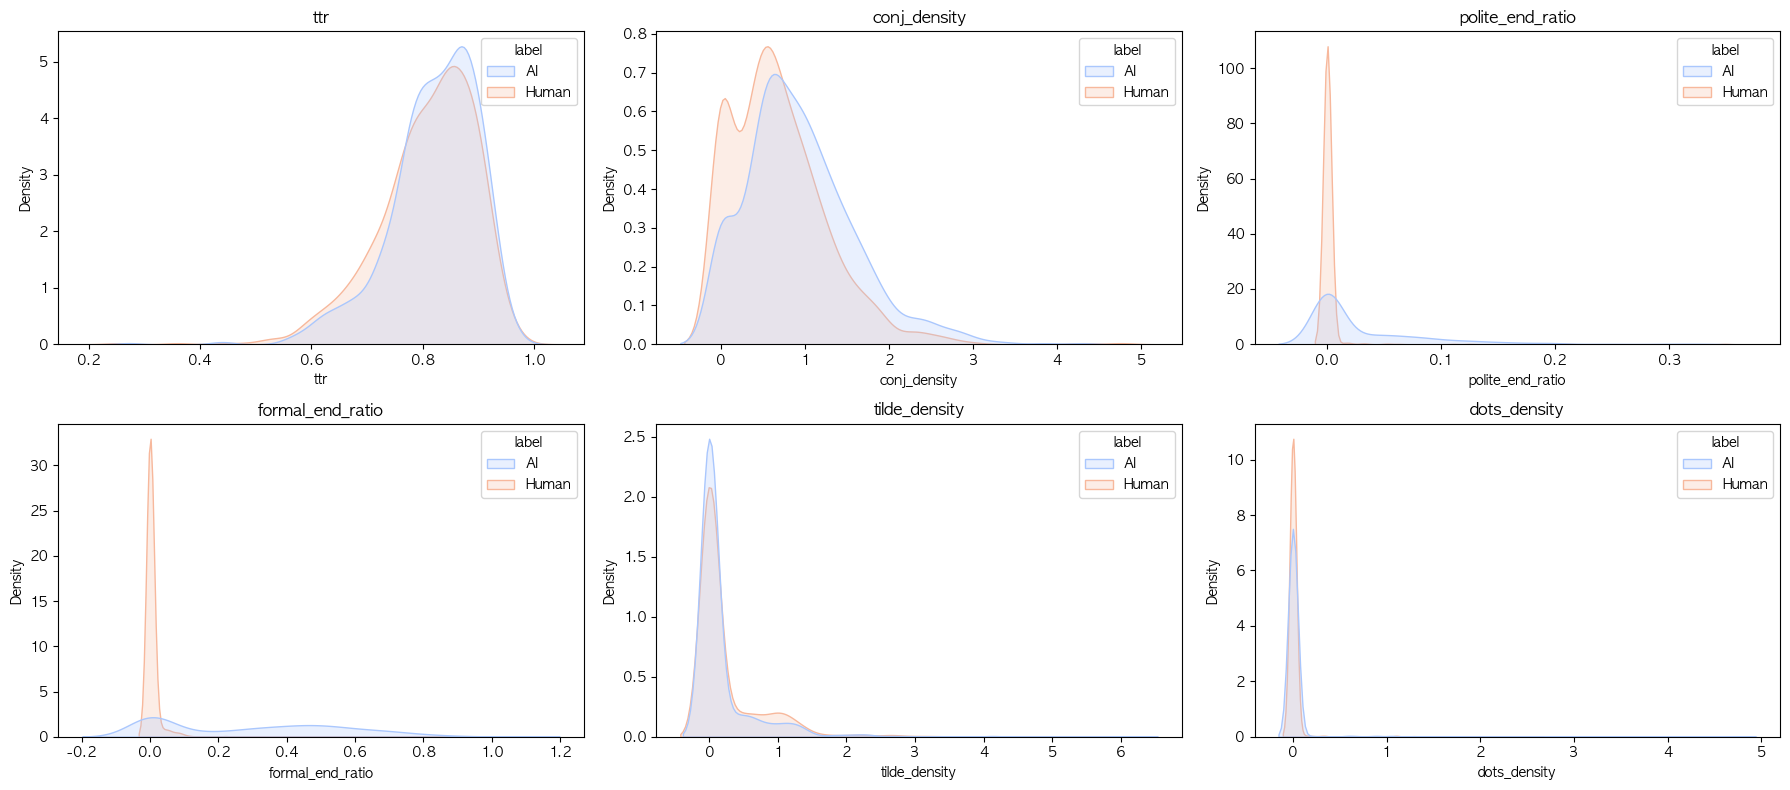

In [38]:
# 스타일 피처 시각화
style_cols = ['ttr', 'conj_density', 'polite_end_ratio', 'formal_end_ratio', 'tilde_density', 'dots_density']

plt.figure(figsize=(18, 8))
for i, col in enumerate(style_cols):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(data=style_df, x=col, hue='label', fill=True, common_norm=False, palette='coolwarm')
    plt.title(f'{col}')

plt.tight_layout()
plt.show()

In [39]:
# 스타일 피처 통계 요약
print("\n📊 Style Feature Summary (Mean by Label):")
display(style_df.groupby('label')[style_cols].mean())


📊 Style Feature Summary (Mean by Label):


,ttr,conj_density,polite_end_ratio,formal_end_ratio,tilde_density,dots_density
label,,,,,,
AI,0.819836,0.928524,0.031893,0.297604,0.190364,0.025749
Human,0.808286,0.680721,0.001180,0.006516,0.252520,0.016062
